In [3]:
from sklearn.datasets import fetch_openml

In [4]:
mnist = fetch_openml('mnist_784', as_frame=False)

In [5]:
X,y = mnist.data ,mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

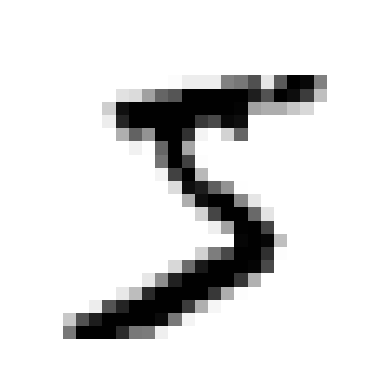

In [6]:
import matplotlib.pyplot as plt
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [7]:
x_train,x_test,y_train,y_test = X[:60000],X[60000:],y[:60000],y[60000:]
from sklearn.linear_model import SGDClassifier
y_train_5= (y_train == '5' )
y_test_5 = (y_test == '5')
sgd_clf = SGDClassifier(random_state=38)
sgd_clf.fit(x_train, y_train_5)



,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",38
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [8]:
sgd_clf.predict([some_digit])

array([ True])

In [9]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,x_train,y_train_5,cv = 4,scoring = "accuracy")

array([0.96506667, 0.9692    , 0.9184    , 0.96793333])

In [10]:
from sklearn.model_selection import cross_val_predict as cp
y_train_pred = cp(sgd_clf,x_train,y_train_5,cv = 3)


In [11]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5,y_train_pred)
cm

array([[54254,   325],
       [ 1929,  3492]])

In [12]:
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7560077938947825

In [13]:
from sklearn.metrics import precision_score,recall_score,precision_recall_curve
prec_sc = precision_score(y_train_5,y_train_pred)
rec_sc = recall_score(y_train_5,y_train_pred)
y_scores = cp(sgd_clf, x_train, y_train_5, cv=3,
method="decision_function")
precisions,recalls,threshold = precision_recall_curve(y_train_5,y_scores)


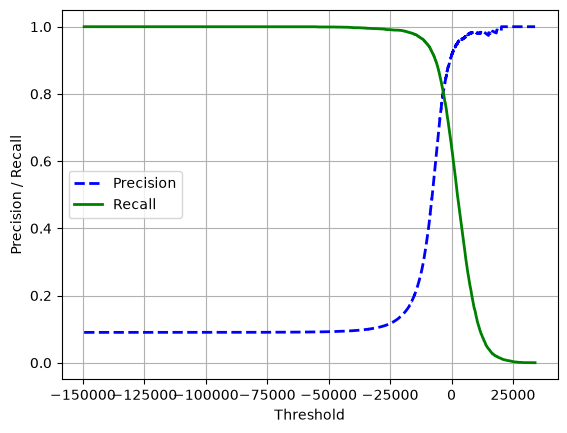

In [14]:
import matplotlib.pyplot as plt
plt.plot(threshold, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(threshold, recalls[:-1], "g-", label="Recall", linewidth=2)

plt.xlabel("Threshold")
plt.ylabel("Precision / Recall")
plt.legend()
plt.grid()
plt.show()

In [15]:
from sklearn.metrics import roc_curve

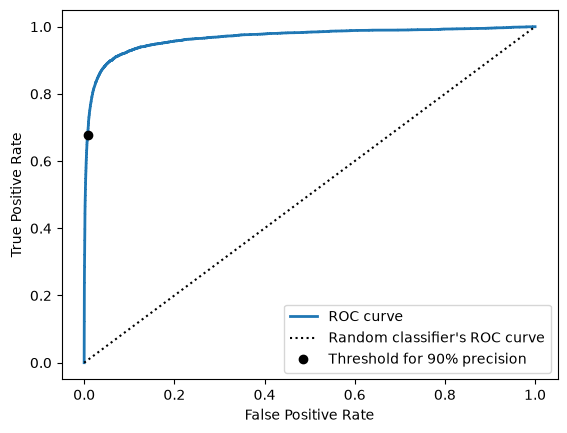

In [16]:
precisions, recalls, thresholds_pr = precision_recall_curve(y_train_5, y_scores)

fpr, tpr, thresholds_roc = roc_curve(y_train_5, y_scores)

idx_for_90_precision = (precisions >= 0.90).argmax()

threshold_for_90_precision = thresholds_pr[idx_for_90_precision]

idx_for_threshold_at_90 = (thresholds_roc <= threshold_for_90_precision).argmax()

tpr_90 = tpr[idx_for_threshold_at_90]
fpr_90 = fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], "k:", label="Random classifier's ROC curve")
plt.plot([fpr_90],[tpr_90],"ko",label="Threshold for 90% precision")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
from sklearn.ensemble import RandomForestClassifier

In [17]:
forest_clf = RandomForestClassifier(random_state = 42)
from sklearn.calibration import CalibratedClassifierCV 
calibrated_clf = CalibratedClassifierCV(forest_clf,cv=3,method="sigmoid")

calibrated_clf.fit(x_train, y_train_5)

y_prob_for = calibrated_clf.predict_proba(x_train)


In [18]:
y_prob_for[:10]

array([[3.73957467e-05, 9.99962604e-01],
       [9.98194471e-01, 1.80552948e-03],
       [9.98009108e-01, 1.99089150e-03],
       [9.98501420e-01, 1.49857987e-03],
       [9.98323200e-01, 1.67680026e-03],
       [9.98393035e-01, 1.60696504e-03],
       [9.98501420e-01, 1.49857987e-03],
       [9.98393035e-01, 1.60696504e-03],
       [9.98501420e-01, 1.49857987e-03],
       [9.98317335e-01, 1.68266490e-03]])

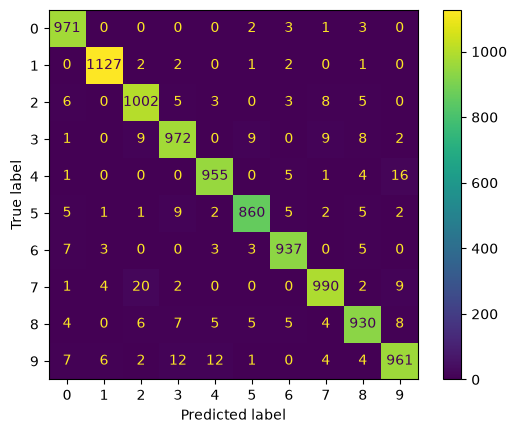

In [26]:
forest_clf.fit(x_train,y_train)
from sklearn.metrics import ConfusionMatrixDisplay
y_pred = forest_clf.predict(x_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

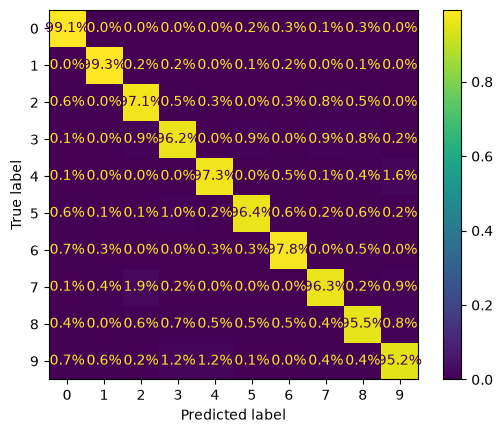

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,normalize = "true",values_format = ".1%"
)


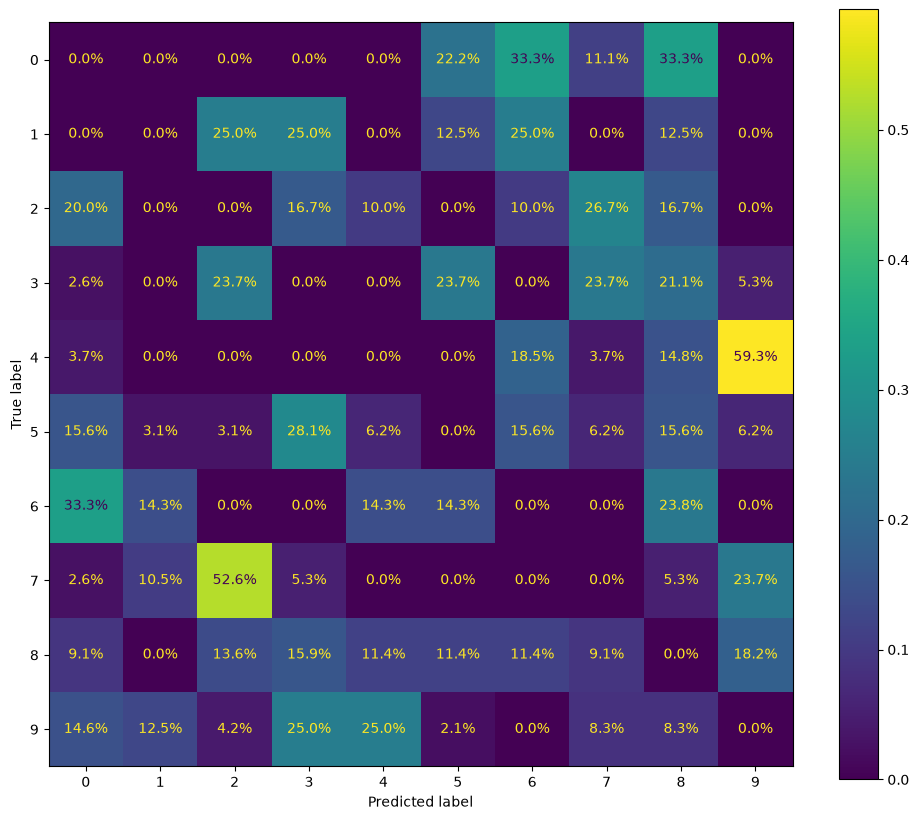

In [40]:
sample_weight = (y_pred != y_test)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
sample_weight=sample_weight,
normalize="true", values_format=".1%",ax=ax)


plt.show()